# Lab 8: Variational Autoencoder (VAE)
**Objective:** Implement a VAE on MNIST, visualize the latent space and generated images.
**Model Chosen:** VAE (Variational Autoencoder)
**Why VAE?** Clean probabilistic framework, interpretable latent space, easy to visualize.

In [1]:
!pip install torch torchvision matplotlib numpy --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load MNIST Dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.64MB/s]


Train: 60000, Test: 10000


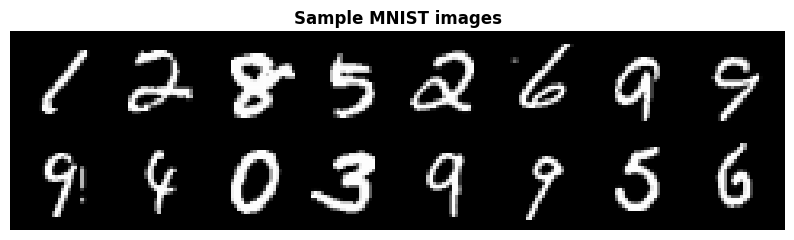

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST('.', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('.', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=128, shuffle=False)
print(f'Train: {len(train_ds)}, Test: {len(test_ds)}')

# Show samples
imgs, labels = next(iter(train_loader))
grid = make_grid(imgs[:16], nrow=8, normalize=True)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1,2,0), cmap='gray')
plt.axis('off'); plt.title('Sample MNIST images', fontweight='bold')
plt.show()

## 2. VAE Architecture

In [4]:
LATENT_DIM = 2  # 2D for visualization

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # Encoder: image → mu, log_var
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU()
        )
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        # Decoder: z → image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid()
        )

    def encode(self, x):
        h    = self.encoder(x)
        mu   = self.fc_mu(h)
        logv = self.fc_log_var(h)
        return mu, logv

    def reparameterize(self, mu, log_var):
        """z = mu + eps * std  (eps ~ N(0,1))"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    """ELBO = Reconstruction Loss + KL Divergence"""
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

model     = VAE(LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(f'VAE parameters: {sum(p.numel() for p in model.parameters()):,}')

VAE parameters: 1,068,820


## 3. Training

In [5]:
EPOCHS = 20
history = {'total': [], 'recon': [], 'kl': []}

for epoch in range(EPOCHS):
    model.train()
    t_loss = r_loss = k_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon, mu, logv = model(imgs)
        loss, rl, kl = vae_loss(recon, imgs, mu, logv)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t_loss += loss.item(); r_loss += rl.item(); k_loss += kl.item()
    N = len(train_loader.dataset)
    history['total'].append(t_loss/N); history['recon'].append(r_loss/N); history['kl'].append(k_loss/N)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Total: {t_loss/N:.2f} | Recon: {r_loss/N:.2f} | KL: {k_loss/N:.2f}')

Epoch 5/20 | Total: 148.83 | Recon: 142.76 | KL: 6.07
Epoch 10/20 | Total: 143.11 | Recon: 136.69 | KL: 6.42
Epoch 15/20 | Total: 140.48 | Recon: 133.86 | KL: 6.62
Epoch 20/20 | Total: 138.71 | Recon: 131.96 | KL: 6.75


## 4. Visualization

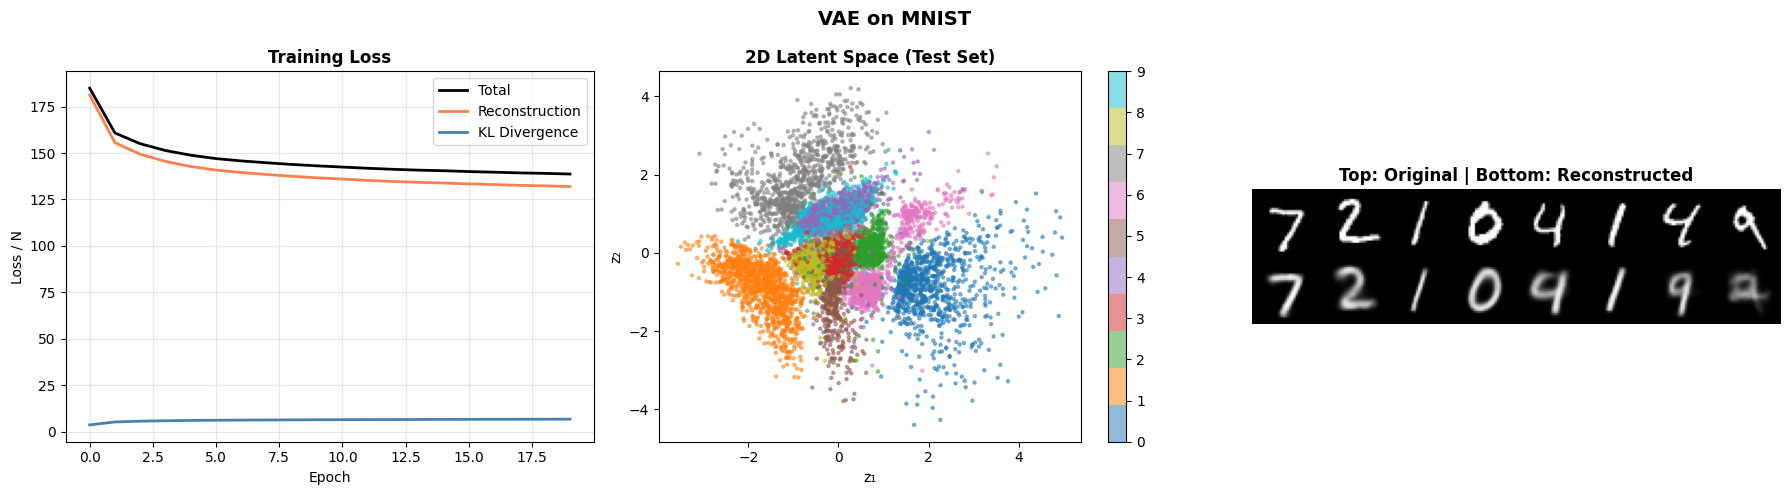

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Training curves
axes[0].plot(history['total'], label='Total',        color='black',   linewidth=2)
axes[0].plot(history['recon'], label='Reconstruction', color='coral',  linewidth=2)
axes[0].plot(history['kl'],    label='KL Divergence',  color='steelblue', linewidth=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss / N')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot B: Latent space (2D)
model.eval()
all_z, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        mu, _ = model.encode(imgs.to(device))
        all_z.append(mu.cpu().numpy())
        all_labels.extend(lbls.numpy())
all_z = np.concatenate(all_z)
all_labels = np.array(all_labels)

scatter = axes[1].scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, ax=axes[1])
axes[1].set_title('2D Latent Space (Test Set)', fontweight='bold')
axes[1].set_xlabel('z₁'); axes[1].set_ylabel('z₂')

# Plot C: Reconstruction
imgs, _ = next(iter(test_loader))
imgs    = imgs[:8].to(device)
with torch.no_grad():
    recon, _, _ = model(imgs)
recon = recon.view(-1, 1, 28, 28).cpu()
combined = torch.cat([imgs.cpu(), recon])
grid = make_grid(combined, nrow=8, normalize=True).permute(1,2,0)
axes[2].imshow(grid, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Top: Original | Bottom: Reconstructed', fontweight='bold')

plt.suptitle('VAE on MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_vae_results.png', dpi=150, bbox_inches='tight')
plt.show()

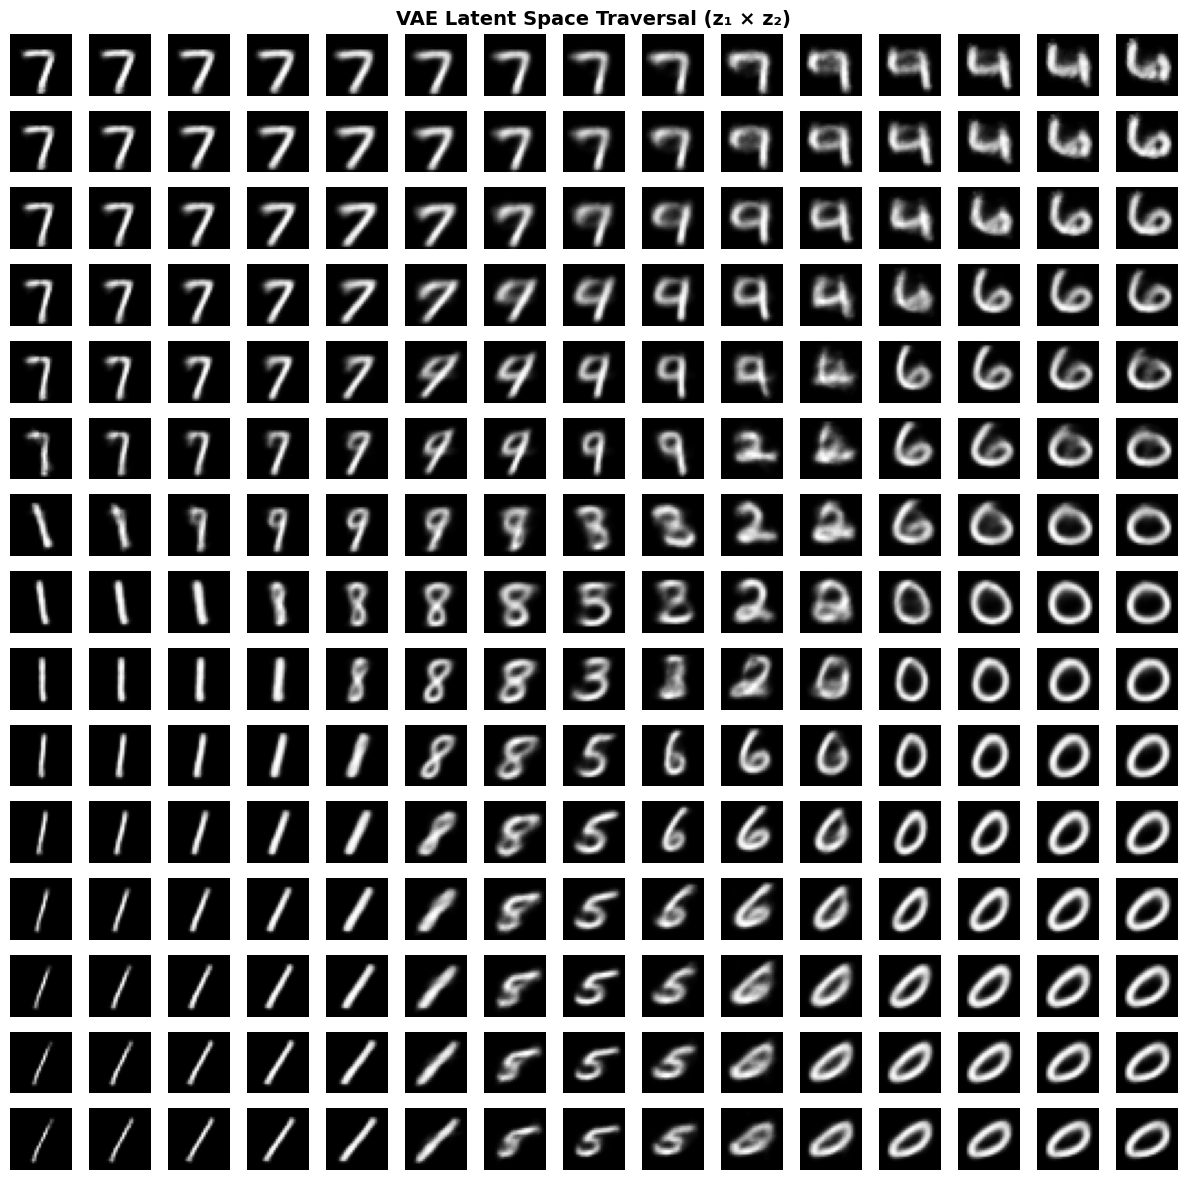

All plots saved.


In [7]:
# Latent space traversal — generate a grid of digits by walking the 2D space
n = 15
grid_range = 2.5
fig, axes = plt.subplots(n, n, figsize=(12, 12))
z1s = np.linspace(-grid_range, grid_range, n)
z2s = np.linspace(-grid_range, grid_range, n)[::-1]

model.eval()
with torch.no_grad():
    for i, z2 in enumerate(z2s):
        for j, z1 in enumerate(z1s):
            z = torch.tensor([[z1, z2]], dtype=torch.float).to(device)
            img = model.decode(z).squeeze().cpu().numpy()
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

plt.suptitle('VAE Latent Space Traversal (z₁ × z₂)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_vae_latent_traversal.png', dpi=150, bbox_inches='tight')
plt.show()
print('All plots saved.')

## 5. Result Explanation

### Model: Variational Autoencoder (VAE)

#### Architecture
- **Encoder**: Maps input image → mean (μ) and log-variance (σ²) of a Gaussian distribution in latent space
- **Reparameterization trick**: z = μ + ε·σ (ε ~ N(0,1)) — makes sampling differentiable
- **Decoder**: Maps z → reconstructed image

#### Loss Function
```
ELBO = Reconstruction Loss + β × KL Divergence
     = -E[log p(x|z)] + β × KL(q(z|x) || p(z))
```
- **Reconstruction loss**: How well the decoder recreates the input (binary cross-entropy)
- **KL divergence**: Forces the latent space to be smooth and close to N(0,1)

#### What the visualizations show
1. **Latent space plot**: Similar digits cluster together. A well-trained VAE has smooth boundaries between clusters — you can interpolate between classes.
2. **Reconstruction**: The model learns to compress and reconstruct handwritten digits.
3. **Latent traversal**: Walking through z-space generates smooth transitions between digit styles — showing the model has learned a structured generative representation.

#### VAE vs GAN vs GCN
| Model | Strength | Use Case |
|-------|----------|----------|
| VAE   | Structured latent space, interpolation | Image generation, anomaly detection |
| GAN   | Sharper images | High-fidelity image synthesis |
| GCN   | Handles graph-structured data | Social networks, molecular graphs |